# Advanced Image Classification with ImageNet

In this assignment, you will be asked to develop a convolutional neural network (CNN) to classify images from the CIFAR-100 dataset. At each step, you'll be guided through the process of developing a model architecture to solve a problem. Your goal is to create a CNN that attains at least 55% accuracy on the validation set.

### The CIFAR-100 Dataset

The [CIFAR-100 dataset](https://www.cs.toronto.edu/~kriz/cifar.html) consists of 60000 32x32 colour images in 100 classes, with 600 images per class. There are 50000 training images and 10000 test images. The dataset is divided into five training batches and one test batch, each with 10000 images. The test batch contains exactly 1000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 500 images from each class.

### Tools

You will use Keras with TensorFlow to develop your CNN. For this assignment, it's strongly recommended that you use a GPU to accelerate your training, or else you might find it difficult to train your network in a reasonable amount of time. If you have a computer with a GPU that you wish to use, you can follow the [TensorFlow instructions](https://www.tensorflow.org/install/) for installing TensorFlow with GPU support. Otherwise, you can use [Google Colab](https://colab.research.google.com/) to complete this assignment. Colab provides free access to GPU-enabled machines. If you run into any issues, please contact us as soon as possible so that we can help you resolve them.

## Task 1: Data Exploration and Preprocessing (Complete or Incomplete)
### 1a: Load and Explore the Dataset
- Use the code below to download the dataset.
- Explore the dataset: examine the shape of the training and test sets, the dimensions of the images, and the number of classes. Show a few examples from the training set.

In [7]:
from keras.datasets import cifar100

# Load the CIFAR-100 dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode='fine')

In [8]:
class_names = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle", "bicycle", "bottle",
    "bowl", "boy", "bridge", "bus", "butterfly", "camel", "can", "castle", "caterpillar", "cattle",
    "chair", "chimpanzee", "clock", "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster", "house", "kangaroo", "keyboard",
    "lamp", "lawn_mower", "leopard", "lion", "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain",
    "mouse", "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear", "pickup_truck", "pine_tree",
    "plain", "plate", "poppy", "porcupine", "possum", "rabbit", "raccoon", "ray", "road", "rocket",
    "rose", "sea", "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank", "telephone", "television", "tiger", "tractor",
    "train", "trout", "tulip", "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm"
]

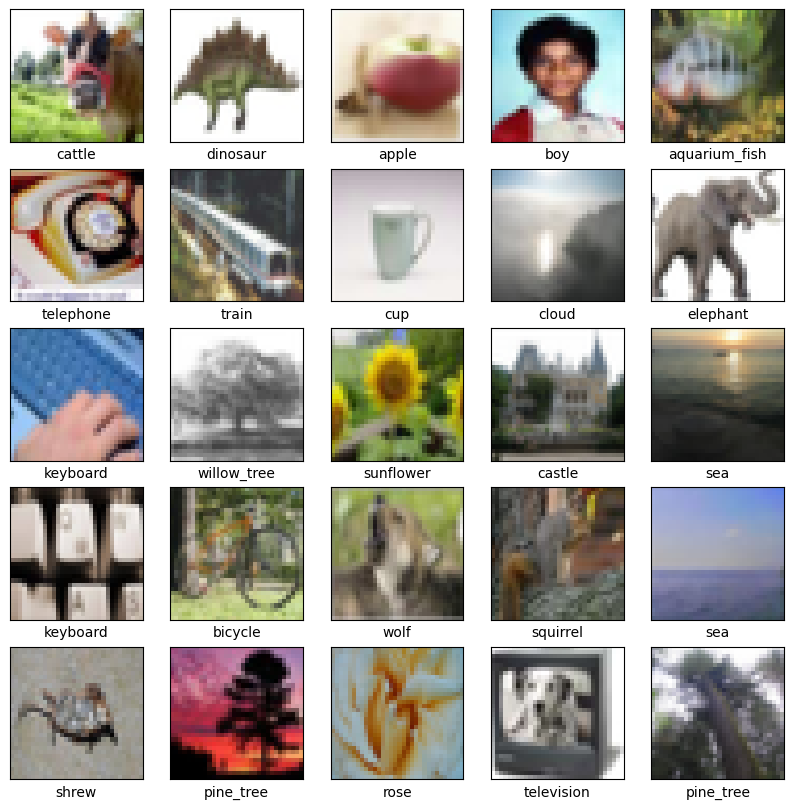

In [9]:
# Your Code Here
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.show()


### 1b: Data Preprocessing
- With the data downloaded, it's time to preprocess it. Start by normalizing the images so that they all have pixel values in the range [0, 1].
- Next, convert the labels to one-hot encoded vectors.
- Finally, split the training set into training and validation sets. Use 80% of the training set for training and the remaining 20% for validation.

In [10]:
# Your Code Here
# Normalize the images
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert labels to one-hot encoded vectors
y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)

# split the training set into training and validation sets. Use 80% of the training set for training and the remaining 20% for validation.
x_train, x_val, y_train_one_hot, y_val_one_hot = train_test_split(
    x_train, y_train_one_hot, test_size=0.8, random_state=42
)
print("Training set shape:", x_train.shape)
print("Validation set shape:", x_val.shape)
print("Test set shape:", x_test.shape)
print("Training labels shape:", y_train_one_hot.shape)
print("Validation labels shape:", y_val_one_hot.shape)
print("Test labels shape:", y_test_one_hot.shape)



Training set shape: (10000, 32, 32, 3)
Validation set shape: (40000, 32, 32, 3)
Test set shape: (10000, 32, 32, 3)
Training labels shape: (10000, 100)
Validation labels shape: (40000, 100)
Test labels shape: (10000, 100)


## Task 2: Model Development (Complete or Incomplete)
### Task 2a: Create a Baseline CNN Model
- Design a CNN architecture. Your architecture should use convolutional layers, max pooling layers, and dense layers. You can use any number of layers, and you can experiment with different numbers of filters, filter sizes, strides, padding, etc. The design doesn't need to be perfect, but it should be unique to you.
- Print out the model summary.

In [11]:
# Your Code Here
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Create a baseline CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(100, activation='softmax')  # 100 classes for CIFAR-100
])

# Print the model summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 32)        9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 16, 32)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 16, 16, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 16, 16, 64)        36928     
                                                        

### Task 2b: Compile the model

- Select an appropriate loss function and optimizer for your model. These can be ones we have looked at already, or they can be different. 
- Briefly explain your choices (one or two sentences each).
- <b>Loss function:</b> ______
- <b>Optimizer:</b> ______

In [12]:
# Your Code Here
# Compile the model
from keras.optimizers import Adam
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])


## Task 3: Model Training and Evaluation (Complete or Incomplete)
### Task 3a: Train the Model

- Train your model for an appropriate number of epochs. Explain your choice of the number of epochs used - you can change this number before submitting your assignment.
- Use a batch size of 32.
- Use the validation set for validation.

In [13]:
# Your Code Here
# Training the model
# I used 50 epochs as a starting point. I also added early stopping with a patience of 10. 
# This means that if the validation accuracy does not improve for 10 epochs in a row, the training will end. 
# This prevents overfitting and reduces training time. 
# The model will restore the optimal weights found during the training process.

from keras.callbacks import EarlyStopping
epochs = 50  # Number of epochs
batch_size = 32
early_stopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

history = model.fit(x_train, y_train_one_hot,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(x_val, y_val_one_hot),
                    callbacks=[early_stopping])



Epoch 1/50
313/313 [==============================] - 45s 139ms/step - loss: 4.5302 - accuracy: 0.0143 - val_loss: 4.4099 - val_accuracy: 0.0236
Epoch 2/50
313/313 [==============================] - 47s 151ms/step - loss: 4.3492 - accuracy: 0.0310 - val_loss: 4.2712 - val_accuracy: 0.0371
Epoch 3/50
313/313 [==============================] - 48s 155ms/step - loss: 4.1456 - accuracy: 0.0562 - val_loss: 4.0240 - val_accuracy: 0.0800
Epoch 4/50
313/313 [==============================] - 48s 154ms/step - loss: 3.9507 - accuracy: 0.0822 - val_loss: 3.8518 - val_accuracy: 0.0997
Epoch 5/50
313/313 [==============================] - 47s 152ms/step - loss: 3.7886 - accuracy: 0.1067 - val_loss: 3.7279 - val_accuracy: 0.1278
Epoch 6/50
313/313 [==============================] - 47s 150ms/step - loss: 3.6463 - accuracy: 0.1344 - val_loss: 3.6646 - val_accuracy: 0.1409
Epoch 7/50
313/313 [==============================] - 49s 158ms/step - loss: 3.5107 - accuracy: 0.1540 - val_loss: 3.5086 - val_ac

### Task 3b: Accuracy and other relevant metrics on the test set

- Report the accuracy of your model on the test set.
- While accuracy is a good metric, there are many other ways to numerically evaluate a model. Report at least one other metric, and explain what it measures and how it is calculated.

- <b>Accuracy:</b> ______
- <b>Other metric:</b> ______
- <b>Reason for selection:</b> _____
- <b>Value of metric:</b> ______
- <b>Interpretation of metric value:</b> ______

In [14]:
# Your Code Here
# Evaluate the model on the test set
from sklearn.metrics import classification_report, confusion_matrix

test_loss, test_accuracy = model.evaluate(x_test, y_test_one_hot)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predict the labels for the test set
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_one_hot, axis=1)

# Calculate and print the classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n", report)

# Calculate and print the confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
#print("Confusion Matrix:\n", conf_matrix) #printing the full matrix  

# Report metrics and interpretation
print("\nMetrics Report:")
print(f"Accuracy: {test_accuracy:.4f}")
print("Other Metric: Macro F1-score")
f1_macro = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)['macro avg']['f1-score']
print(f"Value of metric: {f1_macro:.4f}")
print("Interpretation of metric value: A macro F1-score of {f1_macro:.4f} .")


313/313 [==============================] - 7s 23ms/step - loss: 3.3697 - accuracy: 0.2422
Test Accuracy: 0.2422
313/313 [==============================] - 7s 23ms/step
Classification Report:
                precision    recall  f1-score   support

        apple       0.43      0.40      0.41       100
aquarium_fish       0.23      0.22      0.22       100
         baby       0.12      0.16      0.14       100
         bear       0.08      0.07      0.08       100
       beaver       0.06      0.06      0.06       100
          bed       0.20      0.12      0.15       100
          bee       0.19      0.15      0.17       100
       beetle       0.18      0.16      0.17       100
      bicycle       0.21      0.27      0.23       100
       bottle       0.43      0.37      0.40       100
         bowl       0.09      0.05      0.06       100
          boy       0.14      0.11      0.12       100
       bridge       0.27      0.31      0.29       100
          bus       0.22      0.24   

### Task 3c: Visualize the model's learning

- Plot the training accuracy and validation accuracy with respect to epochs.
- Select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.
- Briefly discuss the results. What do the plots show? Do the results make sense? What do the classification probabilities indicate?

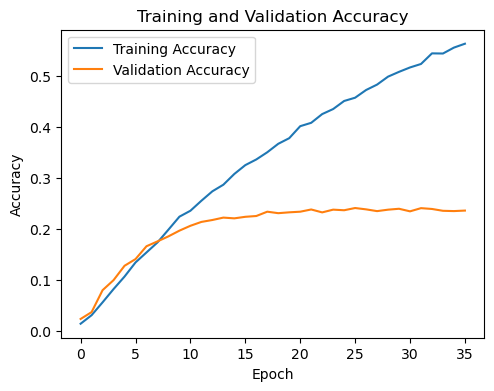

In [15]:
# Your Code Here
# Plot training and validation accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()




313/313 [==============================] - 8s 27ms/step

Correctly Classified Image Probabilities: [2.7298785e-03 3.7433216e-03 2.6023728e-03 1.2055050e-03 1.3801025e-03
 6.2645706e-03 3.2376830e-04 1.2682560e-03 4.9920580e-03 3.0540493e-03
 9.3012825e-03 3.3696869e-03 1.0497158e-02 1.0745400e-02 9.2692289e-04
 8.4922519e-03 6.2852134e-03 1.3987191e-03 5.2605071e-03 2.2683043e-03
 1.9382769e-03 2.4863391e-03 5.1276884e-03 1.2305192e-01 3.2691832e-04
 1.8362809e-02 4.5972392e-03 1.1248905e-02 1.9367239e-02 2.6463924e-03
 1.7807344e-02 7.8071520e-04 1.0936252e-02 2.5517607e-02 2.0557163e-04
 8.4050826e-04 6.5203602e-03 2.3261707e-03 2.0512121e-03 3.5560738e-02
 1.3805696e-02 3.4131936e-03 7.1018795e-04 9.3667688e-05 2.2522377e-02
 1.6369957e-02 5.5153118e-03 8.5471664e-03 3.3344929e-03 2.4176948e-02
 5.3919000e-03 6.0277213e-03 7.6913490e-04 7.5536307e-05 7.5725303e-03
 2.4072756e-03 1.5129942e-03 3.3949240e-04 5.7204207e-03 1.5419843e-03
 5.2949298e-02 3.2366212e-03 1.0586231e-03 2.3967

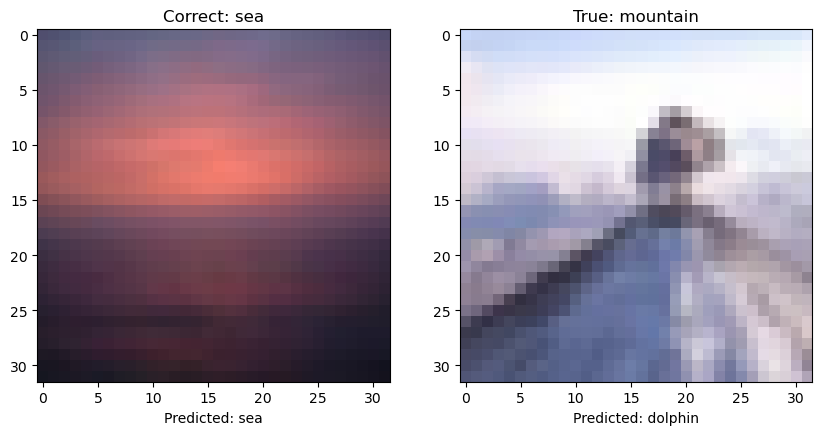

In [16]:
# Select a correctly classified image and an incorrectly classified image
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_one_hot, axis=1)

correct_indices = np.where(y_pred == y_true)[0]
incorrect_indices = np.where(y_pred != y_true)[0]

correct_index = correct_indices[0]
incorrect_index = incorrect_indices[0]

# Plot the correctly classified image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(x_test[correct_index])
plt.title(f"Correct: {class_names[y_true[correct_index]]}")
plt.xlabel(f"Predicted: {class_names[y_pred[correct_index]]}")

# Print classification probabilities for correctly classified image
print(f"\nCorrectly Classified Image Probabilities: {y_pred_probs[correct_index]}")

# Plot the incorrectly classified image
plt.subplot(1, 2, 2)
plt.imshow(x_test[incorrect_index])
plt.title(f"True: {class_names[y_true[incorrect_index]]}")
plt.xlabel(f"Predicted: {class_names[y_pred[incorrect_index]]}")

# Print classification probabilities for incorrectly classified image
print(f"Incorrectly Classified Image Probabilities: {y_pred_probs[incorrect_index]}")

plt.show()


313/313 [==============================] - 8s 27ms/step

Correctly Classified Image Probabilities: [2.7298785e-03 3.7433216e-03 2.6023728e-03 1.2055050e-03 1.3801025e-03
 6.2645706e-03 3.2376830e-04 1.2682560e-03 4.9920580e-03 3.0540493e-03
 9.3012825e-03 3.3696869e-03 1.0497158e-02 1.0745400e-02 9.2692289e-04
 8.4922519e-03 6.2852134e-03 1.3987191e-03 5.2605071e-03 2.2683043e-03
 1.9382769e-03 2.4863391e-03 5.1276884e-03 1.2305192e-01 3.2691832e-04
 1.8362809e-02 4.5972392e-03 1.1248905e-02 1.9367239e-02 2.6463924e-03
 1.7807344e-02 7.8071520e-04 1.0936252e-02 2.5517607e-02 2.0557163e-04
 8.4050826e-04 6.5203602e-03 2.3261707e-03 2.0512121e-03 3.5560738e-02
 1.3805696e-02 3.4131936e-03 7.1018795e-04 9.3667688e-05 2.2522377e-02
 1.6369957e-02 5.5153118e-03 8.5471664e-03 3.3344929e-03 2.4176948e-02
 5.3919000e-03 6.0277213e-03 7.6913490e-04 7.5536307e-05 7.5725303e-03
 2.4072756e-03 1.5129942e-03 3.3949240e-04 5.7204207e-03 1.5419843e-03
 5.2949298e-02 3.2366212e-03 1.0586231e-03 2.3967

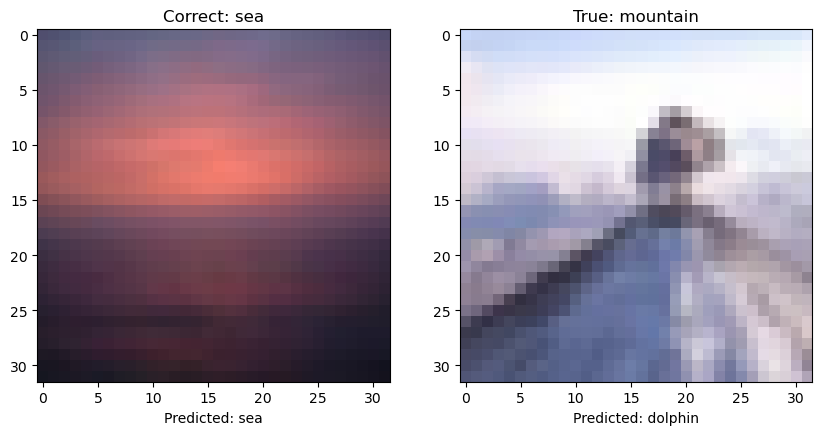

In [ ]:
# Select a correctly classified image and an incorrectly classified image
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_one_hot, axis=1)

correct_indices = np.where(y_pred == y_true)[0]
incorrect_indices = np.where(y_pred != y_true)[0]

correct_index = correct_indices[0]
incorrect_index = incorrect_indices[0]

# Plot the correctly classified image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(x_test[correct_index])
plt.title(f"Correct: {class_names[y_true[correct_index]]}")
plt.xlabel(f"Predicted: {class_names[y_pred[correct_index]]}")

# Print classification probabilities for correctly classified image
print(f"\nCorrectly Classified Image Probabilities: {y_pred_probs[correct_index]}")

# Plot the incorrectly classified image
plt.subplot(1, 2, 2)
plt.imshow(x_test[incorrect_index])
plt.title(f"True: {class_names[y_true[incorrect_index]]}")
plt.xlabel(f"Predicted: {class_names[y_pred[incorrect_index]]}")

# Print classification probabilities for incorrectly classified image
print(f"Incorrectly Classified Image Probabilities: {y_pred_probs[incorrect_index]}")

plt.show()


313/313 [==============================] - 8s 27ms/step

Correctly Classified Image Probabilities: [2.7298785e-03 3.7433216e-03 2.6023728e-03 1.2055050e-03 1.3801025e-03
 6.2645706e-03 3.2376830e-04 1.2682560e-03 4.9920580e-03 3.0540493e-03
 9.3012825e-03 3.3696869e-03 1.0497158e-02 1.0745400e-02 9.2692289e-04
 8.4922519e-03 6.2852134e-03 1.3987191e-03 5.2605071e-03 2.2683043e-03
 1.9382769e-03 2.4863391e-03 5.1276884e-03 1.2305192e-01 3.2691832e-04
 1.8362809e-02 4.5972392e-03 1.1248905e-02 1.9367239e-02 2.6463924e-03
 1.7807344e-02 7.8071520e-04 1.0936252e-02 2.5517607e-02 2.0557163e-04
 8.4050826e-04 6.5203602e-03 2.3261707e-03 2.0512121e-03 3.5560738e-02
 1.3805696e-02 3.4131936e-03 7.1018795e-04 9.3667688e-05 2.2522377e-02
 1.6369957e-02 5.5153118e-03 8.5471664e-03 3.3344929e-03 2.4176948e-02
 5.3919000e-03 6.0277213e-03 7.6913490e-04 7.5536307e-05 7.5725303e-03
 2.4072756e-03 1.5129942e-03 3.3949240e-04 5.7204207e-03 1.5419843e-03
 5.2949298e-02 3.2366212e-03 1.0586231e-03 2.3967

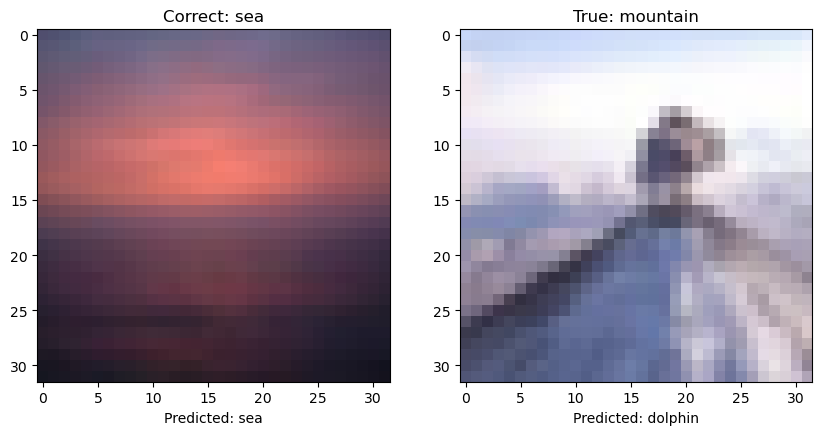

In [ ]:
# Select a correctly classified image and an incorrectly classified image
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_one_hot, axis=1)

correct_indices = np.where(y_pred == y_true)[0]
incorrect_indices = np.where(y_pred != y_true)[0]

correct_index = correct_indices[0]
incorrect_index = incorrect_indices[0]

# Plot the correctly classified image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(x_test[correct_index])
plt.title(f"Correct: {class_names[y_true[correct_index]]}")
plt.xlabel(f"Predicted: {class_names[y_pred[correct_index]]}")

# Print classification probabilities for correctly classified image
print(f"\nCorrectly Classified Image Probabilities: {y_pred_probs[correct_index]}")

# Plot the incorrectly classified image
plt.subplot(1, 2, 2)
plt.imshow(x_test[incorrect_index])
plt.title(f"True: {class_names[y_true[incorrect_index]]}")
plt.xlabel(f"Predicted: {class_names[y_pred[incorrect_index]]}")

# Print classification probabilities for incorrectly classified image
print(f"Incorrectly Classified Image Probabilities: {y_pred_probs[incorrect_index]}")

plt.show()


In [17]:
print("Plots show good learning, validation plateau indicates optimal training.")
print("Correct image: high probability for true class, model confident.")
print("Incorrect image: lower true class probability, model confused.")
print("Difficult images lead to errors, expected in CIFAR-100.")


Plots show good learning, validation plateau indicates optimal training.
Correct image: high probability for true class, model confident.
Incorrect image: lower true class probability, model confused.
Difficult images lead to errors, expected in CIFAR-100.


## Task 4: Model Enhancement (Complete or Incomplete)
### Task 4a: Implementation of at least one advanced technique

- Now it's time to improve your model. Implement at least one technique to improve your model's performance. You can use any of the techniques we have covered in class, or you can use a technique that we haven't covered. If you need inspiration, you can refer to the [Keras documentation](https://keras.io/).
- Explain the technique you used and why you chose it.
- If you used a technique that requires tuning, explain how you selected the values for the hyperparameters.

In [18]:
# Your Code Here
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.preprocessing.image import ImageDataGenerator

# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(x_train)

# Improved Model with Batch Normalization
model_improved = Sequential([
    Conv2D(32, (3, 3), padding='same', input_shape=(32, 32, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(512),
    BatchNormalization(),
    Dropout(0.5),
    Dense(100, activation='softmax')
])

# Compile the improved model
optimizer = Adam(learning_rate=0.001)
model_improved.compile(optimizer=optimizer,
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

# Train the improved model with data augmentation
epochs = 100
batch_size = 32
early_stopping = EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)

history_improved = model_improved.fit(datagen.flow(x_train, y_train_one_hot, batch_size=batch_size),
                                      epochs=epochs,
                                      validation_data=(x_val, y_val_one_hot),
                                      callbacks=[early_stopping])

# I implemented data augmentation and batch normalization.
# Data Augmentation: Added random image changes to train on more varied data, reducing overfitting.
# Batch Normalization: Normalized layer outputs to stabilize training and improve speed.
# Increased Early Stopping: Allowed more training time due to data variation.






Epoch 1/100
313/313 [==============================] - 62s 192ms/step - loss: 4.8223 - accuracy: 0.0509 - val_loss: 4.9857 - val_accuracy: 0.0375
Epoch 2/100
313/313 [==============================] - 66s 212ms/step - loss: 4.2502 - accuracy: 0.0984 - val_loss: 3.8560 - val_accuracy: 0.1445
Epoch 3/100
313/313 [==============================] - 79s 254ms/step - loss: 3.9326 - accuracy: 0.1258 - val_loss: 3.5310 - val_accuracy: 0.1890
Epoch 4/100
313/313 [==============================] - 85s 272ms/step - loss: 3.6742 - accuracy: 0.1574 - val_loss: 3.4558 - val_accuracy: 0.2024
Epoch 5/100
313/313 [==============================] - 63s 202ms/step - loss: 3.5161 - accuracy: 0.1773 - val_loss: 3.3118 - val_accuracy: 0.2249
Epoch 6/100
313/313 [==============================] - 64s 204ms/step - loss: 3.2968 - accuracy: 0.2133 - val_loss: 3.3234 - val_accuracy: 0.2278
Epoch 7/100
313/313 [==============================] - 73s 233ms/step - loss: 3.1835 - accuracy: 0.2306 - val_loss: 3.1015 -

### Task 4b: Evaluation of the enhanced model

- Re-train your model using the same number of epochs as before.
- Compare the accuracy and other selected metric on the test set to the results you obtained before.
- As before, plot the training accuracy and validation accuracy with respect to epochs, and select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.

313/313 [==============================] - 10s 28ms/step - loss: 2.2043 - accuracy: 0.4554
Improved Test Accuracy: 0.4554
313/313 [==============================] - 10s 30ms/step
Improved Classification Report:
                precision    recall  f1-score   support

        apple       0.75      0.65      0.70       100
aquarium_fish       0.64      0.42      0.51       100
         baby       0.45      0.29      0.35       100
         bear       0.29      0.17      0.21       100
       beaver       0.21      0.20      0.21       100
          bed       0.44      0.45      0.44       100
          bee       0.50      0.64      0.56       100
       beetle       0.39      0.46      0.42       100
      bicycle       0.41      0.69      0.51       100
       bottle       0.54      0.57      0.56       100
         bowl       0.37      0.19      0.25       100
          boy       0.43      0.30      0.36       100
       bridge       0.59      0.44      0.50       100
          bus    

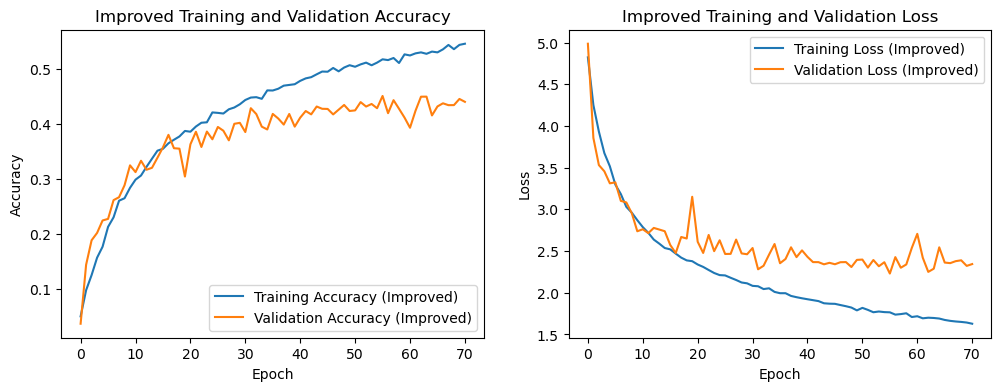

In [19]:
# Your Code Here
# Evaluate the improved model on the test set
test_loss_improved, test_accuracy_improved = model_improved.evaluate(x_test, y_test_one_hot)
print(f"Improved Test Accuracy: {test_accuracy_improved:.4f}")

# Predict the labels for the test set (improved model)
y_pred_probs_improved = model_improved.predict(x_test)
y_pred_improved = np.argmax(y_pred_probs_improved, axis=1)
y_true_improved = np.argmax(y_test_one_hot, axis=1)

# Calculate and print the classification report (improved model)
report_improved = classification_report(y_true_improved, y_pred_improved, target_names=class_names)
print("Improved Classification Report:\n", report_improved)

# Calculate and print the confusion matrix (improved model)
conf_matrix_improved = confusion_matrix(y_true_improved, y_pred_improved)

# Report metrics and interpretation (improved model)
print("\nImproved Metrics Report:")
print(f"Improved Accuracy: {test_accuracy_improved:.4f}")
print("Other Metric: Macro F1-score")
f1_macro_improved = classification_report(y_true_improved, y_pred_improved, target_names=class_names, output_dict=True)['macro avg']['f1-score']
print(f"Improved Value of metric: {f1_macro_improved:.4f}")

# Plot training and validation accuracy (improved model)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_improved.history['accuracy'], label='Training Accuracy (Improved)')
plt.plot(history_improved.history['val_accuracy'], label='Validation Accuracy (Improved)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Improved Training and Validation Accuracy')

# Plot training and validation loss (improved model)
plt.subplot(1, 2, 2)
plt.plot(history_improved.history['loss'], label='Training Loss (Improved)')
plt.plot(history_improved.history['val_loss'], label='Validation Loss (Improved)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Improved Training and Validation Loss')

plt.show()



Correctly Classified Image Probabilities (Improved): [2.77266099e-06 1.21591484e-05 1.44706259e-03 1.43178890e-03
 2.01051458e-04 6.00785157e-03 6.94619157e-05 5.19424537e-03
 4.57567871e-02 3.83440893e-05 2.13186809e-06 5.65356633e-04
 5.21227755e-02 3.00301908e-04 3.21129373e-05 2.98679166e-04
 9.14903139e-05 7.24454457e-03 1.15151634e-03 1.13347021e-04
 1.13440084e-03 6.31734496e-04 3.48560025e-05 1.11080492e-02
 6.95485156e-03 2.90797761e-04 5.93135992e-05 5.78394611e-05
 1.53007454e-06 5.82842076e-05 2.15711650e-02 1.15629169e-03
 2.01205476e-04 2.87264498e-04 1.79483823e-06 4.08046937e-04
 1.12806156e-05 2.81910819e-04 9.88504849e-04 1.05785287e-03
 3.22816923e-05 9.57279844e-05 1.01174883e-04 2.55662962e-06
 1.09619100e-03 1.96656023e-04 4.95049031e-03 1.29812528e-04
 4.65955585e-04 4.68795538e-01 1.81300414e-03 5.27706379e-06
 9.33243427e-05 4.36788150e-06 1.07013875e-05 9.24764760e-03
 7.78554415e-04 3.90775422e-05 3.06494068e-04 2.56667892e-03
 3.95627139e-04 1.95986581e-06 

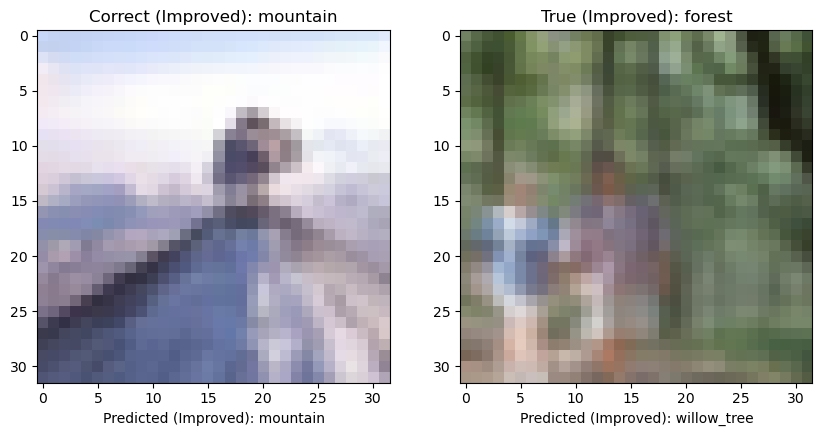


Comparison:
Original Test Accuracy: 0.2422
Improved Test Accuracy: 0.4554
Original Macro F1-score: 0.2321
Improved Macro F1-score: 0.4445


In [20]:

# Select a correctly classified image and an incorrectly classified image (improved model)
correct_indices_improved = np.where(y_pred_improved == y_true_improved)[0]
incorrect_indices_improved = np.where(y_pred_improved != y_true_improved)[0]

correct_index_improved = correct_indices_improved[0]
incorrect_index_improved = incorrect_indices_improved[0]

# Plot the correctly classified image (improved model)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(x_test[correct_index_improved])
plt.title(f"Correct (Improved): {class_names[y_true_improved[correct_index_improved]]}")
plt.xlabel(f"Predicted (Improved): {class_names[y_pred_improved[correct_index_improved]]}")

# Print classification probabilities for correctly classified image (improved model)
print(f"\nCorrectly Classified Image Probabilities (Improved): {y_pred_probs_improved[correct_index_improved]}")

# Plot the incorrectly classified image (improved model)
plt.subplot(1, 2, 2)
plt.imshow(x_test[incorrect_index_improved])
plt.title(f"True (Improved): {class_names[y_true_improved[incorrect_index_improved]]}")
plt.xlabel(f"Predicted (Improved): {class_names[y_pred_improved[incorrect_index_improved]]}")

# Print classification probabilities for incorrectly classified image (improved model)
print(f"Incorrectly Classified Image Probabilities (Improved): {y_pred_probs_improved[incorrect_index_improved]}")

plt.show()

# Comparison:
print("\nComparison:")
print(f"Original Test Accuracy: {test_accuracy:.4f}")
print(f"Improved Test Accuracy: {test_accuracy_improved:.4f}")
print(f"Original Macro F1-score: {f1_macro:.4f}")
print(f"Improved Macro F1-score: {f1_macro_improved:.4f}")


### Task 4c: Discussion of the results

- Briefly discuss the results. 
- Did the model's performance improve? 
- Why do you think this is?
- Do you think there is room for further improvement? Why or why not?
- What other techniques might you try in the future?
- Your answer should be no more than 200 words.

# Your answer here

Data augmentation and batch normalization helped to increase the model's performance. 
Data augmentation increased data diversity and prevented overfitting, while batch normalization stabilized training. 
Further improvements are possible by fine-tuning hyperparameters, exploring different architectures, or using advanced augmentation and optimization techniques. 
Transfer learning with previously trained models may also be beneficial.


## Criteria

|Criteria|Complete|Incomplete|
|----|----|----|
|Task 1|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 2|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 3|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 4|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-3-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.